<a href="https://colab.research.google.com/github/gopalstud86/GenAI-Assignments/blob/main/Bronze%20Badge%20Assignments/Problem3_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt

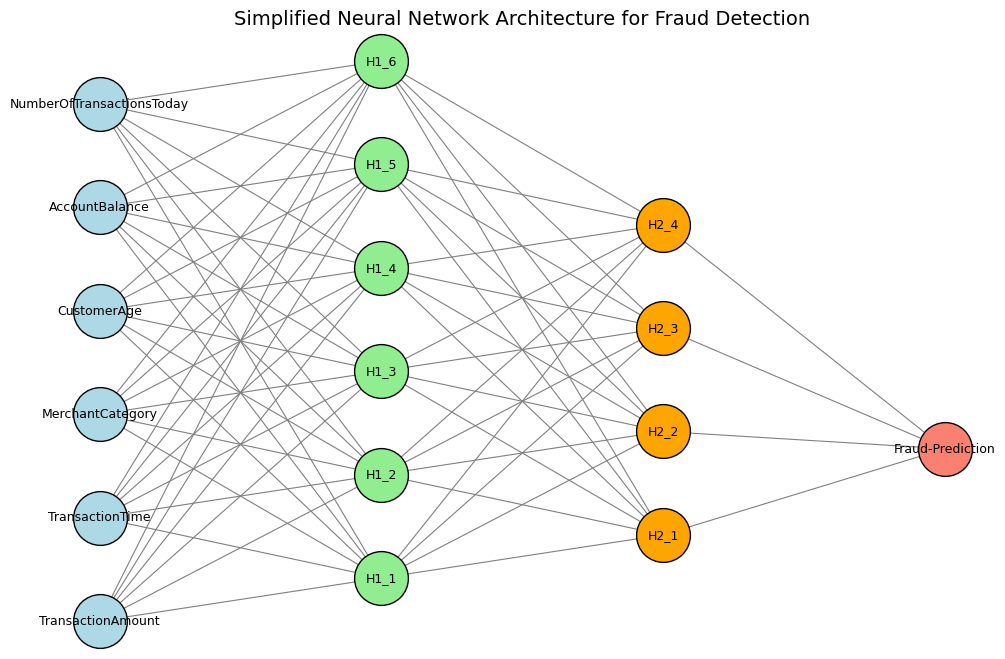

In [6]:
# -----------------------------
# Define the layers
# -----------------------------
input_features = ["TransactionAmount","TransactionTime","MerchantCategory",
                  "CustomerAge","AccountBalance","NumberOfTransactionsToday"]

hidden_layer1 = [f"H1_{i}" for i in range(1, 7)]
hidden_layer2 = [f"H2_{i}" for i in range(1, 5)]
output_layer = ["Fraud-Prediction"]

# -----------------------------
# Helper function to draw nodes
# -----------------------------
def draw_layer(nodes, x, y_start, spacing, color):
    positions = {}
    for i, node in enumerate(nodes):
        y = y_start + i * spacing
        plt.scatter(x, y, s=1500, c=color, edgecolors="black", zorder=3)
        plt.text(x, y, node, ha="center", va="center", fontsize=9, zorder=4)
        positions[node] = (x, y)
    return positions

# -----------------------------
# Draw the network
# -----------------------------
plt.figure(figsize=(12, 8))

pos_input = draw_layer(input_features, x=0, y_start=0, spacing=1.2, color="lightblue")
pos_h1 = draw_layer(hidden_layer1, x=2, y_start=0.5, spacing=1.2, color="lightgreen")
pos_h2 = draw_layer(hidden_layer2, x=4, y_start=1, spacing=1.2, color="orange")
pos_output = draw_layer(output_layer, x=6, y_start=2, spacing=1.2, color="salmon")

# -----------------------------
# Draw connections
# -----------------------------
def connect_layers(layer1, layer2, pos1, pos2):
    for n1 in layer1:
        for n2 in layer2:
            x1, y1 = pos1[n1]
            x2, y2 = pos2[n2]
            plt.plot([x1, x2], [y1, y2], "gray", linewidth=0.8, zorder=1)

connect_layers(input_features, hidden_layer1, pos_input, pos_h1)
connect_layers(hidden_layer1, hidden_layer2, pos_h1, pos_h2)
connect_layers(hidden_layer2, output_layer, pos_h2, pos_output)

plt.title("Simplified Neural Network Architecture for Fraud Detection", fontsize=14)
plt.axis("off")
plt.show()


Saved diagram to 'fraud_nn_architecture.png


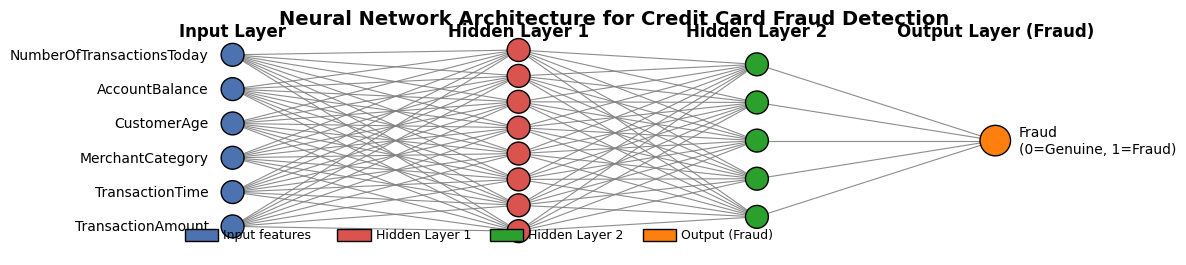

In [4]:
"""
fraud_nn_architecture.py

Draws a neural network architecture diagram for fraud detection:
- Input Layer (6 labeled features)
- Hidden Layer 1 (8 red nodes)
- Hidden Layer 2 (5 green nodes)
- Output Layer (1 orange node labeled Fraud)

Requirements:
    pip install matplotlib numpy

Run:
    python fraud_nn_architecture.py

This script saves the diagram as 'fraud_nn_architecture.png' and displays it.
"""

import matplotlib.pyplot as plt
import numpy as np

def draw_layer(ax, x, y_positions, node_color, edge_color='k', node_radius=0.12, labels=None, label_offset=(0,0), fontsize=10):
    """
    Draw nodes (circles) at positions (x, y_positions).
    Optionally annotate each node with labels (string list) placed with label_offset.
    Returns list of node center coordinates for connection drawing.
    """
    centers = []
    for i, y in enumerate(y_positions):
        circle = plt.Circle((x, y), node_radius, color=node_color, ec=edge_color, zorder=3)
        ax.add_patch(circle)
        centers.append((x, y))
        if labels is not None:
            lx = x + label_offset[0]
            ly = y + label_offset[1]
            ax.text(lx, ly, labels[i], ha='left' if label_offset[0] >= 0 else 'right',
                    va='center', fontsize=fontsize)
    return centers

def connect_layers(ax, centers_a, centers_b, line_color='gray', lw=0.8, alpha=0.9):
    """
    Draw straight lines connecting every node in centers_a to every node in centers_b.
    centers_* are lists of (x,y) tuples.
    """
    for (x1, y1) in centers_a:
        for (x2, y2) in centers_b:
            ax.plot([x1, x2], [y1, y2], color=line_color, linewidth=lw, alpha=alpha, zorder=1)

def evenly_spaced_positions(n, y_min=-1.0, y_max=1.0):
    """
    Return n y positions evenly spaced between y_max and y_min (top to bottom).
    """
    if n == 1:
        return [(y_max + y_min) / 2.0]
    return list(np.linspace(y_max, y_min, n))

def main():
    # Figure setup
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(-1.2, 1.2)
    ax.axis('off')
    plt.gca().set_aspect('equal', adjustable='box')

    # Layer x positions
    x_input = 1.0
    x_h1 = 4.0
    x_h2 = 6.5
    x_out = 9.0

    # Node counts
    n_input = 6
    n_h1 = 8
    n_h2 = 5
    n_out = 1

    # Input feature labels (top to bottom)
    input_labels = [
        "NumberOfTransactionsToday",
        "AccountBalance",
        "CustomerAge",
        "MerchantCategory",
        "TransactionTime",
        "TransactionAmount"
    ]

    # Compute vertical positions (top to bottom)
    y_input = evenly_spaced_positions(n_input, y_min=-0.9, y_max=0.9)
    y_h1 = evenly_spaced_positions(n_h1, y_min=-0.95, y_max=0.95)
    y_h2 = evenly_spaced_positions(n_h2, y_min=-0.8, y_max=0.8)
    y_out = evenly_spaced_positions(n_out, y_min=-0.0, y_max=0.0)

    # Draw layers
    input_centers = draw_layer(ax, x_input, y_input, node_color='#4C72B0', edge_color='k',
                               node_radius=0.12, labels=input_labels, label_offset=(-0.25, 0), fontsize=10)
    h1_centers = draw_layer(ax, x_h1, y_h1, node_color='#D9534F', edge_color='k',
                            node_radius=0.12, labels=None)
    h2_centers = draw_layer(ax, x_h2, y_h2, node_color='#2CA02C', edge_color='k',
                            node_radius=0.12, labels=None)
    out_centers = draw_layer(ax, x_out, y_out, node_color='#FF7F0E', edge_color='k',
                             node_radius=0.16, labels=None)

    # Connect layers fully (input -> h1 -> h2 -> out)
    connect_layers(ax, input_centers, h1_centers, line_color='gray', lw=0.8, alpha=0.9)
    connect_layers(ax, h1_centers, h2_centers, line_color='gray', lw=0.8, alpha=0.9)
    connect_layers(ax, h2_centers, out_centers, line_color='gray', lw=0.8, alpha=0.9)

    # Layer titles
    ax.text(x_input, 1.05, "Input Layer", ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(x_h1, 1.05, "Hidden Layer 1", ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(x_h2, 1.05, "Hidden Layer 2", ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(x_out, 1.05, "Output Layer (Fraud)", ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Annotate output node label
    ax.text(x_out + 0.25, y_out[0], "Fraud\n(0=Genuine, 1=Fraud)", ha='left', va='center', fontsize=10)

    # Add small legend boxes for colors
    legend_x = 0.5
    legend_y = -1.05
    box_w = 0.35
    box_h = 0.12
    # Input
    ax.add_patch(plt.Rectangle((legend_x, legend_y), box_w, box_h, color='#4C72B0', ec='k', zorder=3))
    ax.text(legend_x + box_w + 0.05, legend_y + box_h/2, "Input features", va='center', fontsize=9)
    # Hidden1
    legend_x += 1.6
    ax.add_patch(plt.Rectangle((legend_x, legend_y), box_w, box_h, color='#D9534F', ec='k', zorder=3))
    ax.text(legend_x + box_w + 0.05, legend_y + box_h/2, "Hidden Layer 1", va='center', fontsize=9)
    # Hidden2
    legend_x += 1.6
    ax.add_patch(plt.Rectangle((legend_x, legend_y), box_w, box_h, color='#2CA02C', ec='k', zorder=3))
    ax.text(legend_x + box_w + 0.05, legend_y + box_h/2, "Hidden Layer 2", va='center', fontsize=9)
    # Output
    legend_x += 1.6
    ax.add_patch(plt.Rectangle((legend_x, legend_y), box_w, box_h, color='#FF7F0E', ec='k', zorder=3))
    ax.text(legend_x + box_w + 0.05, legend_y + box_h/2, "Output (Fraud)", va='center', fontsize=9)

    # Title
    ax.text(5.0, 1.18, "Neural Network Architecture for Credit Card Fraud Detection", ha='center', va='bottom',
            fontsize=14, fontweight='bold')

    # Tight layout and save
    plt.tight_layout()
    plt.savefig('fraud_nn_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved diagram to 'fraud_nn_architecture.png")
    plt.show()

if __name__ == '__main__':
    main()
